In [1]:
import zipfile
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
with zipfile.ZipFile('diabetic_data.csv.zip') as z:
    with z.open('diabetic_data.csv') as f:
        df = pd.read_csv(f)

df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [2]:
print("\nSummary Statistics for Numerical Columns:")
print(df.describe())


Summary Statistics for Numerical Columns:
       encounter_id   patient_nbr  admission_type_id  \
count  1.017660e+05  1.017660e+05      101766.000000   
mean   1.652016e+08  5.433040e+07           2.024006   
std    1.026403e+08  3.869636e+07           1.445403   
min    1.252200e+04  1.350000e+02           1.000000   
25%    8.496119e+07  2.341322e+07           1.000000   
50%    1.523890e+08  4.550514e+07           1.000000   
75%    2.302709e+08  8.754595e+07           3.000000   
max    4.438672e+08  1.895026e+08           8.000000   

       discharge_disposition_id  admission_source_id  time_in_hospital  \
count             101766.000000        101766.000000     101766.000000   
mean                   3.715642             5.754437          4.395987   
std                    5.280166             4.064081          2.985108   
min                    1.000000             1.000000          1.000000   
25%                    1.000000             1.000000          2.000000   
50%     

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [4]:
print('According to the data there are total 50 columns')
df_cat = df.select_dtypes(include='object')
df_num = df.select_dtypes(include='number')
print('Total categorical columns : ',len(df_cat.columns))
print('\nCategorical column names : ',df_cat.columns)
print('\nTotal numerical columns: ',len(df_num.columns))
print('\nNumerical column names : ',df_num.columns)

According to the data there are total 50 columns
Total categorical columns :  37

Categorical column names :  Index(['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty',
       'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

Total numerical columns:  13

Numerical column names :  Index(['encounter_id', 'patient_nbr', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medi

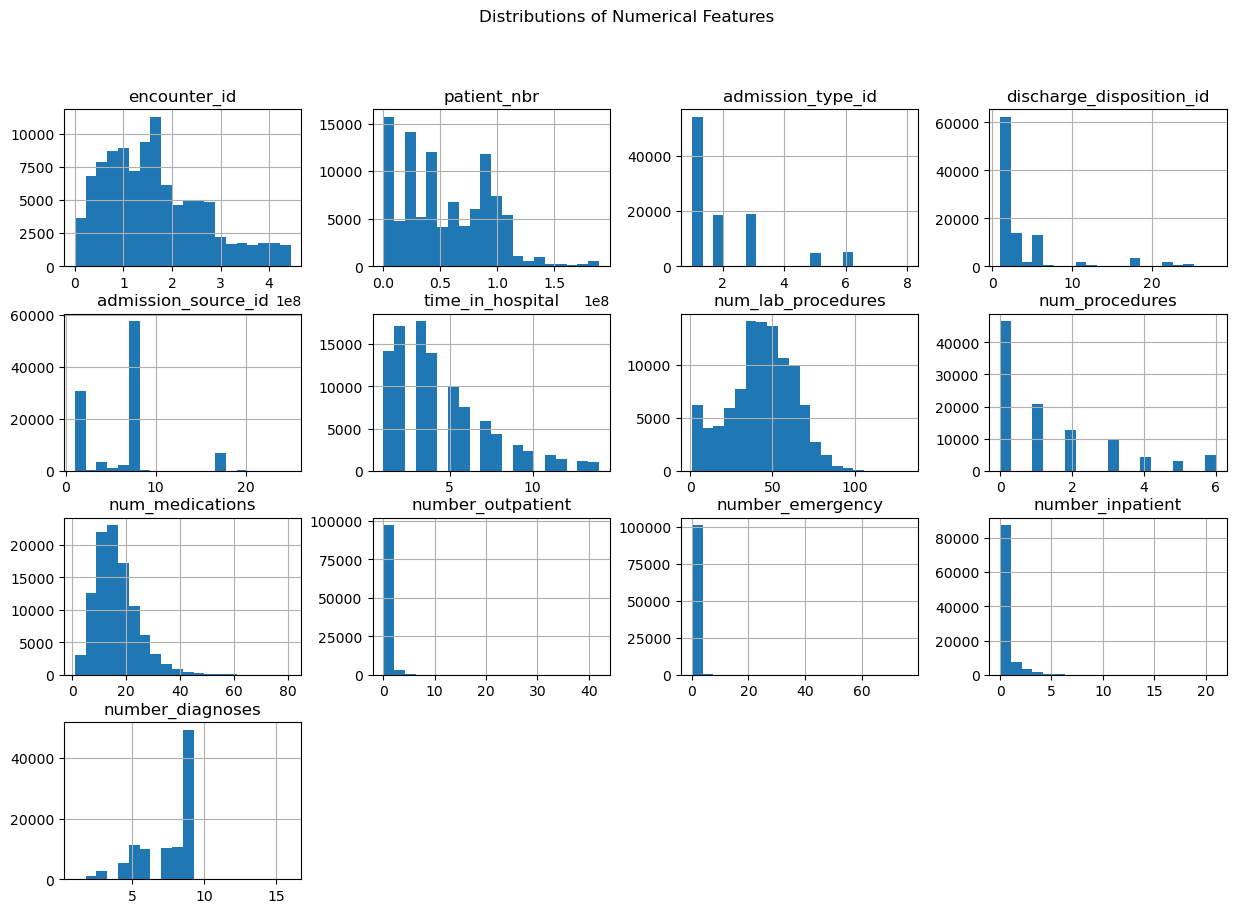

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize distributions of numerical columns
df[df_num.columns].hist(figsize=(15, 10), bins=20)
plt.suptitle("Distributions of Numerical Features")
plt.show()

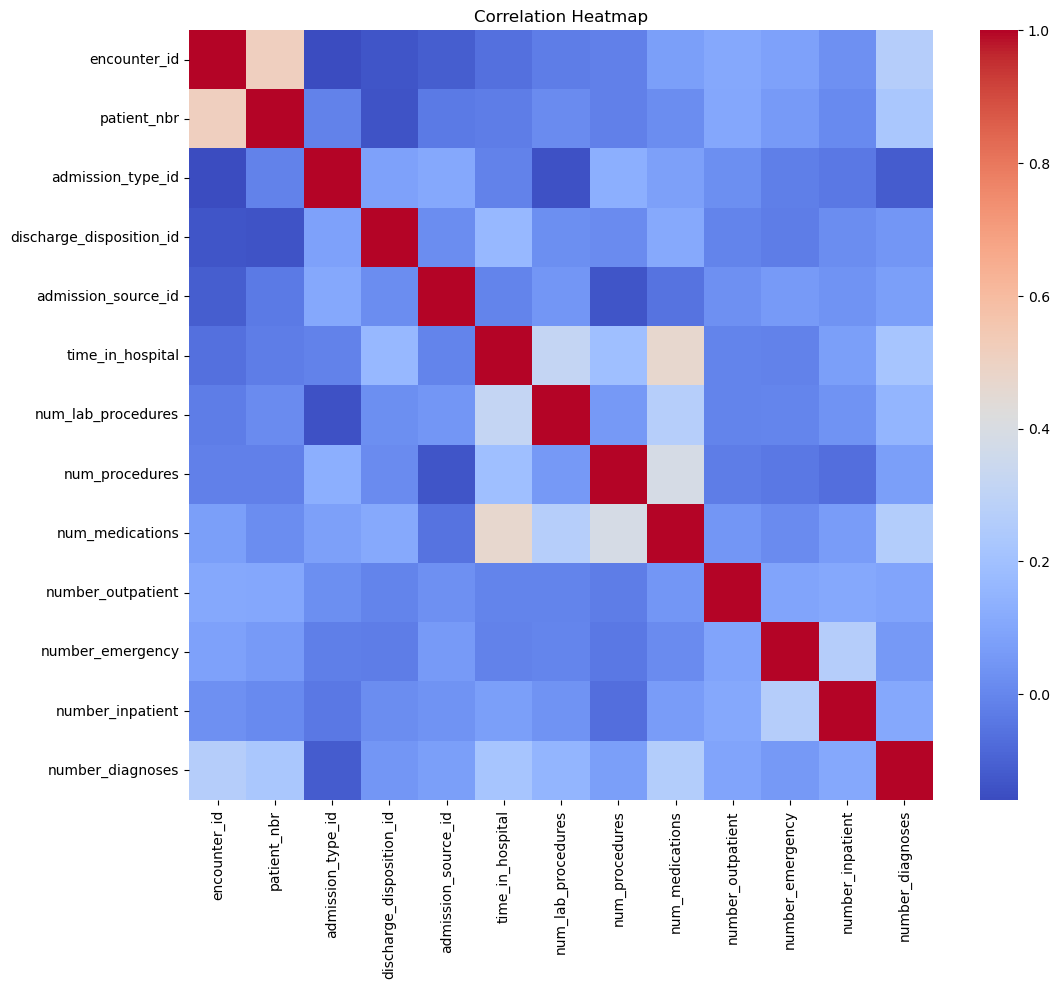

In [6]:
# Plotting a heatmap to visualize the correlation matrix with no annotations and a 'coolwarm' color map
plt.figure(figsize=(12, 10))
correlation_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [7]:

# Check for unique values and '?' in categorical columns

for col in df_cat.columns:
    print(f"{col} - Missing placeholders ('?'): {df[col].isin(['?']).sum()}")

race - Missing placeholders ('?'): 2273
gender - Missing placeholders ('?'): 0
age - Missing placeholders ('?'): 0
weight - Missing placeholders ('?'): 98569
payer_code - Missing placeholders ('?'): 40256
medical_specialty - Missing placeholders ('?'): 49949
diag_1 - Missing placeholders ('?'): 21
diag_2 - Missing placeholders ('?'): 358
diag_3 - Missing placeholders ('?'): 1423
max_glu_serum - Missing placeholders ('?'): 0
A1Cresult - Missing placeholders ('?'): 0
metformin - Missing placeholders ('?'): 0
repaglinide - Missing placeholders ('?'): 0
nateglinide - Missing placeholders ('?'): 0
chlorpropamide - Missing placeholders ('?'): 0
glimepiride - Missing placeholders ('?'): 0
acetohexamide - Missing placeholders ('?'): 0
glipizide - Missing placeholders ('?'): 0
glyburide - Missing placeholders ('?'): 0
tolbutamide - Missing placeholders ('?'): 0
pioglitazone - Missing placeholders ('?'): 0
rosiglitazone - Missing placeholders ('?'): 0
acarbose - Missing placeholders ('?'): 0
mig

In [8]:
# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

Missing values in each column:
race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
max_glu_serum        96420
A1Cresult            84748
dtype: int64


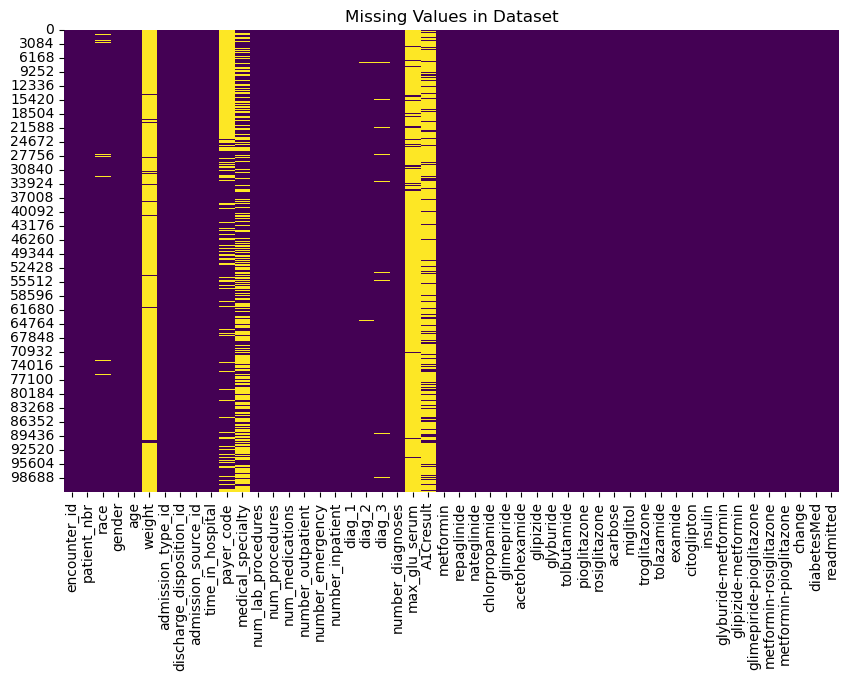

In [9]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values[missing_values > 0])

# Visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values in Dataset")
plt.show()

Percentage of Missing Values:
weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64


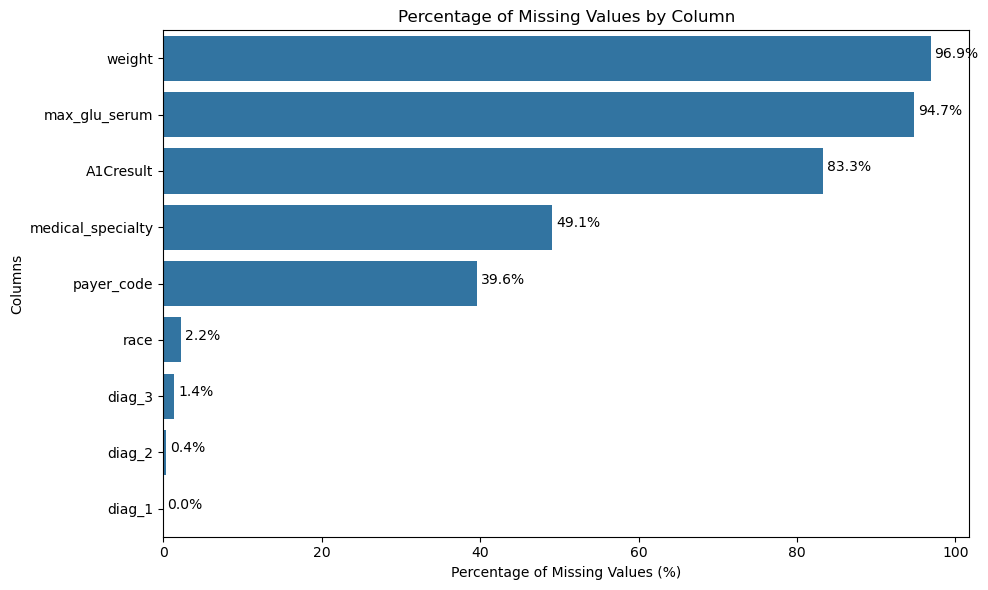

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the number of missing values in each column
missing_values = df.isnull().sum()

# Convert to percentage
missing_percentage = (missing_values / len(df)) * 100

# Keep only columns that have missing values
missing_percentage = missing_percentage[missing_percentage > 0]

# Sort from highest to lowest
missing_percentage = missing_percentage.sort_values(ascending=False)

# Print the percentages
print("Percentage of Missing Values:")
print(missing_percentage)

# Plot the missing value percentages
plt.figure(figsize=(10,6))

sns.barplot(
    x=missing_percentage.values,
    y=missing_percentage.index
)

plt.title('Percentage of Missing Values by Column')
plt.xlabel('Percentage of Missing Values (%)')
plt.ylabel('Columns')

# Add percentage labels on bars
for i, v in enumerate(missing_percentage.values):
    plt.text(v + 0.5, i, f'{v:.1f}%')

plt.tight_layout()
plt.show()

In [11]:

# Drop irrelevant columns having maximum missing values
df = df.drop(['weight', 'payer_code', 'medical_specialty', 'max_glu_serum', 'A1Cresult'], axis = 1,errors='ignore')

In [12]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Remove duplicates if any
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"New dataset shape after removing duplicates: {df.shape}")
else:
    print("No duplicates found.")

Number of duplicate rows: 0
No duplicates found.


In [13]:
print(df['encounter_id'].nunique())
print(df['patient_nbr'].nunique())
df.drop(['encounter_id', 'patient_nbr'],axis=1, inplace=True)

101766
71518


In [14]:
#exploring the modified dataset
df.columns

Index(['race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
       'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
       'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
       'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
       'glipizide-metformin', 'glimepiride-pioglitazone',
       'metformin-rosiglitazone', 'metformin-pioglitazone', 'change',
       'diabetesMed', 'readmitted'],
      dtype='object')

In [15]:
df.isnull().sum()

race                        2273
gender                         0
age                            0
admission_type_id              0
discharge_disposition_id       0
admission_source_id            0
time_in_hospital               0
num_lab_procedures             0
num_procedures                 0
num_medications                0
number_outpatient              0
number_emergency               0
number_inpatient               0
diag_1                        21
diag_2                       358
diag_3                      1423
number_diagnoses               0
metformin                      0
repaglinide                    0
nateglinide                    0
chlorpropamide                 0
glimepiride                    0
acetohexamide                  0
glipizide                      0
glyburide                      0
tolbutamide                    0
pioglitazone                   0
rosiglitazone                  0
acarbose                       0
miglitol                       0
troglitazo

In [16]:
#feature cleaning in the race column
# Print the count of unique values in the 'race' column before cleaning
print(df['race'].value_counts())

# Print the unique values in the 'race' column to see all distinct races present in the dataset
print(df['race'].unique())

race
Caucasian          76099
AfricanAmerican    19210
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64
['Caucasian' 'AfricanAmerican' nan 'Other' 'Asian' 'Hispanic']


In [17]:
# Impute missing/nan values for categorical columns using mode
df['race'] = df['race'].fillna(df['race'].mode()[0])

Text(0.5, 1.0, 'Race Distribution')

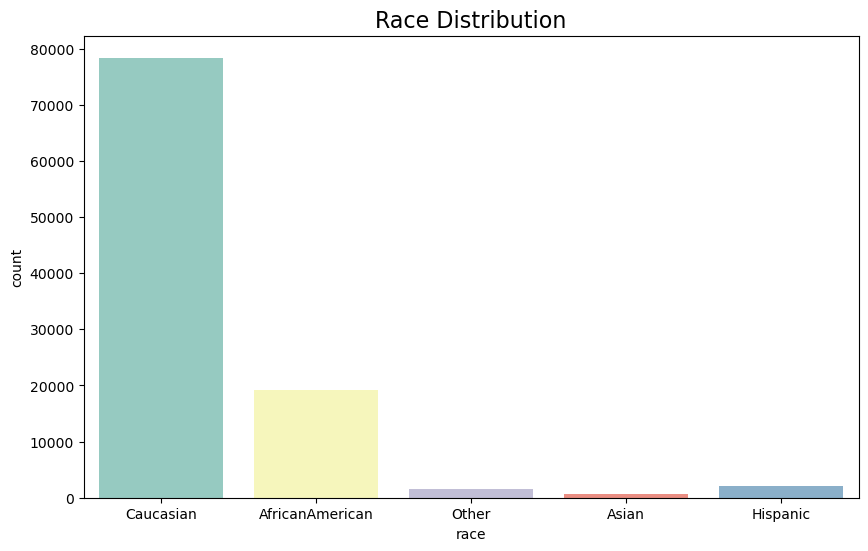

In [18]:
# Set the figure size to 10x6 inches for the plot
plt.figure(figsize=(10, 6))

# Generate a color palette with a unique color for each race category in the 'race' column
colors = sns.color_palette("Set3", len(df['race'].unique()))  # Generate unique colors

# Create a count plot to visualize the distribution of races in the 'race' column
sns.countplot(data=df, x='race', palette=colors)

# Set the title of the plot to "Race Distribution" and adjust the font size to 16
plt.title("Race Distribution", fontsize=16)


In [19]:
#feature cleaning and encoding categorical variables in gender column
# Print the counts of each unique value in the 'gender' column
print(df['gender'].value_counts())

# Print the unique values in the 'gender' column before cleaning
print(df['gender'].unique())

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64
['Female' 'Male' 'Unknown/Invalid']


In [20]:

# Replace 'Unknown/Invalid' values in the 'gender' column with NaN
df['gender'] = df['gender'].replace('Unknown/Invalid', np.nan)

# Drop any rows with NaN values in the 'gender' column (removes invalid or missing gender entries)
df['gender'].dropna(inplace=True)

# Fill any remaining NaN values with the most frequent value (mode) in the 'gender' column
# This step is precautionary, as dropna() should remove most NaN values
df['gender'].fillna(df['gender'].mode()[0], inplace=True)

# Print the unique values in the 'gender' column after cleaning
print(df['gender'].unique())

# Print the counts of each unique value in the 'gender' column (how many 'Female' and 'Male')
print(df['gender'].value_counts())

['Female' 'Male']
gender
Female    54711
Male      47055
Name: count, dtype: int64


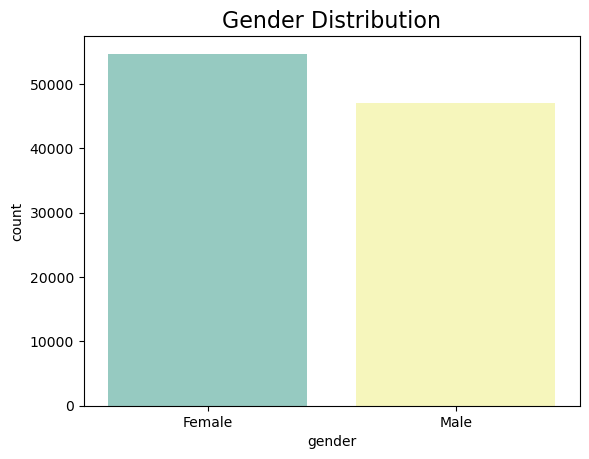

In [21]:
# Create a count plot to visualize the distribution of gender
sns.countplot(data=df, x='gender', palette=colors)

# Set the title of the plot to "Gender Distribution" and adjust the font size
plt.title("Gender Distribution", fontsize=16)

# Show the plot
plt.show()

In [22]:
# Display the count of unique values in the 'gender' column
df['gender'].value_counts()

# Replace 'Female' with 0 and 'Male' with 1 in the 'gender' column for easier modeling
df['gender'] = df['gender'].replace({'Female' : 0, 'Male' : 1})

In [23]:

# Print the counts of each unique value in the 'age' column before transformation
df['age'].value_counts()

age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

In [24]:
# Replace age ranges with midpoints
df['age'] = df['age'].replace({
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
})

# Print the counts of each unique value in the 'age' column after transformation
df.age.value_counts()

age
75    26068
65    22483
55    17256
85    17197
45     9685
35     3775
95     2793
25     1657
15      691
5       161
Name: count, dtype: int64

In [25]:
# Print the counts of each unique value in the 'admission_type_id' column before transformation
df['admission_type_id'].value_counts()

admission_type_id
1    53990
3    18869
2    18480
6     5291
5     4785
8      320
7       21
4       10
Name: count, dtype: int64

In [26]:
# Extract the zip file
with zipfile.ZipFile('diabetic_data_new.zip', 'r') as zip_ref:
    zip_ref.extractall('new_dataset')

# Read IDS_mapping.csv
ID_map = pd.read_csv('new_dataset/IDS_mapping.csv')

# Display columns
ID_map[['admission_type_id', 'description']].head(8)

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NaN
6,7,Trauma Center
7,8,Not Mapped


In [27]:
#Emergency, Urgent and Trauma center come under single category
#Not Available, NaN and Not Mapped means the same
df['admission_type_id']=df['admission_type_id'].replace({1:'Emergency', 2 :'Emergency', 7: 'Emergency', 5: 'Not Available', 6: 'Not Available', 8: 'Not Available', 3: 'Elective', 4: 'Newborn'})
df['admission_type_id'].value_counts()

admission_type_id
Emergency        72491
Elective         18869
Not Available    10396
Newborn             10
Name: count, dtype: int64

Text(0.5, 1.0, 'Admission type category Distribution')

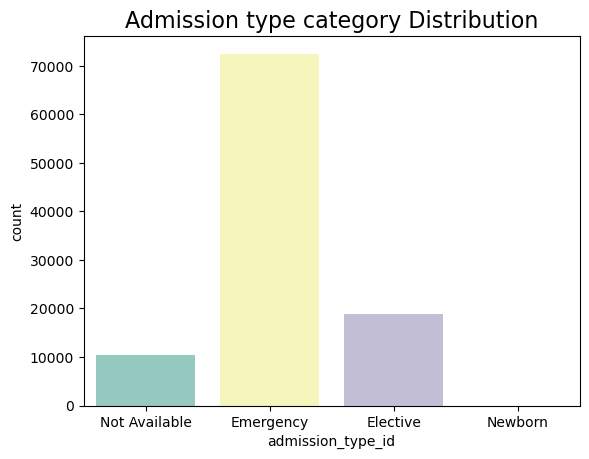

In [28]:
#countplot to visualize the distribution of admission types in the 'admission_type_id' column
sns.countplot(data=df, x='admission_type_id', palette=colors)
plt.title("Admission type category Distribution", fontsize=16)

In [29]:
# Drop rows from the DataFrame where the 'admission_type_id' is 'Newborn'
df.drop(df.index[df['admission_type_id'] == 'Newborn'], inplace=True)

# Display the count of each unique value in the 'admission_type_id' column after removing 'Newborn' records
df['admission_type_id'].value_counts()

admission_type_id
Emergency        72491
Elective         18869
Not Available    10396
Name: count, dtype: int64

In [30]:

ID_map.loc[9:, ['admission_type_id', 'description']].head(30)

,admission_type_id,description
9,discharge_disposition_id,description
10,1,Discharged to home
11,2,Discharged/transferred to another short term h...
12,3,Discharged/transferred to SNF
13,4,Discharged/transferred to ICF
14,5,Discharged/transferred to another type of inpa...
15,6,Discharged/transferred to home with home healt...
16,7,Left AMA
17,8,Discharged/transferred to home under care of H...
18,9,Admitted as an inpatient to this hospital


In [31]:
# function to categorize discharge dispositions
def categorize_discharge(disposition_id):
    if disposition_id in [1, 6, 8]:
        return 'Discharged to home'
    elif disposition_id in [2, 3, 4, 5, 16, 22, 23, 24, 27, 28, 29, 30]:
        return 'Transferred to another facility'
    elif disposition_id == 7:
        return 'Left AMA'  # Left Against Medical Advice
    elif disposition_id in [9, 12, 15, 17]:
        return 'Still patient/referred to this institution'
    elif disposition_id == 10:
        return 'Neonate discharged'
    elif disposition_id in [11, 19, 20, 21]:
        return 'Expired'
    elif disposition_id in [13, 14]:
        return 'Hospice'
    elif disposition_id in [18, 25, 26]:
        return 'Not Available'
    else:
        return 'Unknown'

# Apply the function to the 'discharge_disposition_id' column
df['discharge_disposition_id'] = df['discharge_disposition_id'].apply(categorize_discharge)
df['discharge_disposition_id'].value_counts()
     

discharge_disposition_id
Discharged to home                            73234
Transferred to another facility               20689
Not Available                                  4680
Expired                                        1652
Hospice                                         771
Left AMA                                        623
Still patient/referred to this institution      101
Neonate discharged                                6
Name: count, dtype: int64

In [32]:
df=df[df['discharge_disposition_id']!='Expired']
df=df[df['discharge_disposition_id']!='Neonate discharged']
df=df[df['discharge_disposition_id']!='Hospice']

In [33]:
ID_map.loc[41:, ['admission_type_id', 'description']].head(15)

,admission_type_id,description
41,admission_source_id,description
42,1,Physician Referral
43,2,Clinic Referral
44,3,HMO Referral
45,4,Transfer from a hospital
46,5,Transfer from a Skilled Nursing Facility (SNF)
47,6,Transfer from another health care facility
48,7,Emergency Room
49,8,Court/Law Enforcement
50,9,Not Available


In [34]:
# Define a function to categorize admission source
def categorize_admission_source(source_id):
    if source_id in [1, 2, 3]:
        return 'Referral'
    elif source_id in [4, 5, 6, 10, 18, 19, 22, 25, 26]:
        return 'Transferred from hospital'
    elif source_id in [7, 8]:
        return 'Emergency'
    elif source_id in [9, 15, 17, 20, 21]:
        return 'Not Available'
    elif source_id in [11, 12, 13, 14, 23, 24]:
        return 'Delivery'
    else:
        return 'Unknown'

# Apply the function to the 'admission_source_id' column
df['admission_source_id'] = df['admission_source_id'].apply(categorize_admission_source)
df['admission_source_id'].value_counts()

admission_source_id
Emergency                    55860
Referral                     30429
Not Available                 6854
Transferred from hospital     6180
Delivery                         4
Name: count, dtype: int64

Text(0.5, 1.0, 'Admission source category distribution')

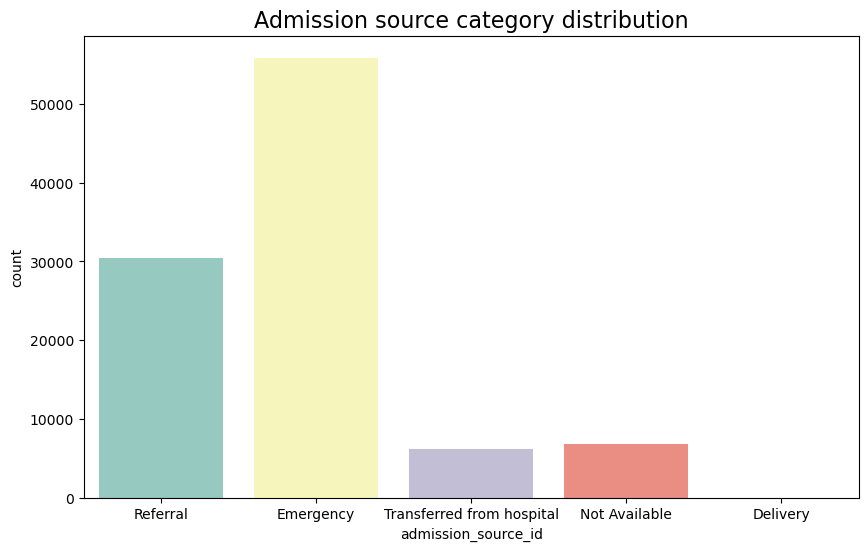

In [35]:
#countplot to visualize the distribution of admission source category in the 'admission_type_id' column
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='admission_source_id', palette=colors)
plt.title("Admission source category distribution", fontsize=16)

In [36]:
df=df[df['admission_source_id']!='Delivery']#cuz there are only 4 such records

In [37]:
# Find the range of lab tests a patient has undergone to understand variability and detect potential outliers
print('The number of lab tests a patient has undergone can range from', df.num_lab_procedures.min(), 'to', df.num_lab_procedures.max())

# Find the range of medications prescribed to identify variability and ensure the data is consistent
print('The number of medications range from a minimum of', df.num_medications.min(), 'to maximum of', df.num_medications.max())

The number of lab tests a patient has undergone can range from 1 to 132
The number of medications range from a minimum of 1 to maximum of 81


In [38]:
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,0,5,Not Available,Not Available,Referral,1,41,0,1,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,0,15,Emergency,Discharged to home,Emergency,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,0,25,Emergency,Discharged to home,Emergency,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,1,35,Emergency,Discharged to home,Emergency,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,1,45,Emergency,Discharged to home,Emergency,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [39]:
# Combine outpatient, emergency, and inpatient visits
df['service_utilization'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']
df.drop(['number_outpatient', 'number_emergency', 'number_inpatient'], axis=1, inplace=True)

In [40]:
# Fill missing values (NaN) in with the most frequent value (mode) in the column
df['diag_1'] = df['diag_1'].fillna(df['diag_1'].mode()[0])
df['diag_2'] = df['diag_2'].fillna(df['diag_2'].mode()[0])
df['diag_3'] = df['diag_3'].fillna(df['diag_3'].mode()[0])

In [41]:
df.isnull().sum()

race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazone                0
tolazamide                  0
examide                     0
citoglipton                 0
insulin                     0
glyburide-metformin         0
glipizide-

In [42]:
# Replace categorical values in 'readmitted' column
df['readmitted'] = df['readmitted'].replace({'>30' : 0, 'NO' : 0, '<30' : 1})

# Display the count of each unique value in the 'readmitted' column
df['readmitted'].value_counts()

readmitted
0    88010
1    11313
Name: count, dtype: int64

In [43]:
# Display the counts of each category in the 'diabetesMed' column
print(df['diabetesMed'].value_counts())

# Replace categorical values in the 'diabetesMed' column with numeric values
df['diabetesMed'] = df['diabetesMed'].replace({'Yes': 1, 'No': 0})

diabetesMed
Yes    76703
No     22620
Name: count, dtype: int64


In [44]:

# Display the counts of each category in the 'change' column
print(df['change'].value_counts())

# Replace categorical values in the 'change' column with numeric values
df['change'] = df['change'].replace({'No': 0, 'Ch': 1})

change
No    53206
Ch    46117
Name: count, dtype: int64


In [45]:
# Create a list of column names for drugs (from columns 16 to 38, inclusive)
drug = list(df.iloc[:, 16:39].columns)
drug

['nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed']

In [46]:
#Print the column name along with the unique values it contains
for i in drug:
  print(i, df[i].unique())

nateglinide ['No' 'Steady' 'Down' 'Up']
chlorpropamide ['No' 'Steady' 'Down' 'Up']
glimepiride ['No' 'Steady' 'Down' 'Up']
acetohexamide ['No' 'Steady']
glipizide ['No' 'Steady' 'Up' 'Down']
glyburide ['No' 'Steady' 'Up' 'Down']
tolbutamide ['No' 'Steady']
pioglitazone ['No' 'Steady' 'Up' 'Down']
rosiglitazone ['No' 'Steady' 'Up' 'Down']
acarbose ['No' 'Steady' 'Up' 'Down']
miglitol ['No' 'Steady' 'Down' 'Up']
troglitazone ['No' 'Steady']
tolazamide ['No' 'Steady' 'Up']
examide ['No']
citoglipton ['No']
insulin ['No' 'Up' 'Steady' 'Down']
glyburide-metformin ['No' 'Steady' 'Down' 'Up']
glipizide-metformin ['No' 'Steady']
glimepiride-pioglitazone ['No' 'Steady']
metformin-rosiglitazone ['No' 'Steady']
metformin-pioglitazone ['No' 'Steady']
change [0 1]
diabetesMed [0 1]


In [47]:

for i in drug:
  print((df[i].value_counts(normalize=True)*100))
  print("\n" + "-"*50 + "\n")

nateglinide
No        99.306304
Steady     0.658458
Up         0.024164
Down       0.011075
Name: proportion, dtype: float64

--------------------------------------------------

chlorpropamide
No        99.915427
Steady     0.077525
Up         0.006041
Down       0.001007
Name: proportion, dtype: float64

--------------------------------------------------

glimepiride
No        94.844095
Steady     4.639409
Up         0.324195
Down       0.192302
Name: proportion, dtype: float64

--------------------------------------------------

acetohexamide
No        99.998993
Steady     0.001007
Name: proportion, dtype: float64

--------------------------------------------------

glipizide
No        87.385601
Steady    11.293457
Up         0.769208
Down       0.551735
Name: proportion, dtype: float64

--------------------------------------------------

glyburide
No        89.407287
Steady     9.222436
Up         0.806460
Down       0.563817
Name: proportion, dtype: float64

-----------------------

In [48]:
for i in drug:
  df[i]= df[i].apply(lambda x: 0 if (x== 'No' or x == 'Steady') else 1)

df['metformin'] = df['metformin'].replace({'No': 0, 'Steady': 0, 'Up': 1, 'Down': 1})
df['repaglinide'] = df['repaglinide'].replace({'No': 0, 'Steady': 0, 'Up': 1, 'Down': 1})

In [49]:
# Create dummy variables for the 'race' column using one-hot encoding
race_dummies = pd.get_dummies(df['race'], drop_first=True)

# Concatenate the newly created dummy variables with the original dataframe (df)
df = pd.concat([df, race_dummies], axis=1)

# Drop the original 'race' column as it is no longer needed after creating the dummy variables
df.drop(['race'], inplace=True, axis=1)

# Display the first few rows of the modified dataframe to verify the changes
df.head()

,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,diag_1,...,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,service_utilization,Asian,Caucasian,Hispanic,Other
0,0,5,Not Available,Not Available,Referral,1,41,0,1,250.83,...,0,0,1,1,0,0,False,True,False,False
1,0,15,Emergency,Discharged to home,Emergency,3,59,0,18,276,...,0,0,1,1,0,0,False,True,False,False
2,0,25,Emergency,Discharged to home,Emergency,2,11,5,13,648,...,0,0,1,1,0,3,False,False,False,False
3,1,35,Emergency,Discharged to home,Emergency,2,44,1,16,8,...,0,0,1,1,0,0,False,True,False,False
4,1,45,Emergency,Discharged to home,Emergency,1,51,0,8,197,...,0,0,1,1,0,0,False,True,False,False


In [50]:
#label encoding for diagnosis column
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Loop through the three diagnosis columns: 'diag_1', 'diag_2', 'diag_3'
for col in ['diag_1', 'diag_2', 'diag_3']:
    # Replace NaN (missing values) with 'Unknown' to handle missing data before encoding
    df[col] = df[col].fillna('Unknown')
    # Apply label encoding to convert categorical values into numeric labels
    df[col] = label_encoder.fit_transform(df[col])

Text(0.5, 1.0, 'Readmitted distribution')

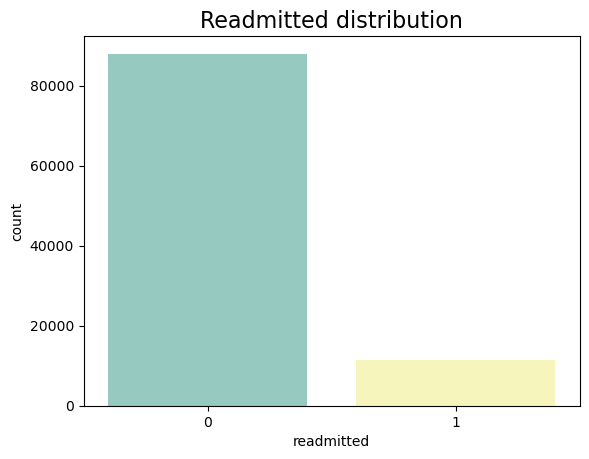

In [51]:
#A countplot helps to understand the frequency of each category in the 'readmitted' column
sns.countplot(data=df, x='readmitted', palette=colors)
plt.title("Readmitted distribution", fontsize=16)

In [52]:
df['readmitted'].value_counts()

readmitted
0    88010
1    11313
Name: count, dtype: int64

In [53]:
# Replace categorical values in 'admission_type_id' with numerical labels
df['admission_type_id'] = df['admission_type_id'].replace({'Emergency': 0, 'Elective': 1, 'Not Available': 2})

# Replace categorical values in 'discharge_disposition_id' with numerical labels
df['discharge_disposition_id'] = df['discharge_disposition_id'].replace({
    'Discharged to home': 0,
    'Transferred to another facility': 1,
    'Not Available': 2,
    'Left AMA': 3,
    'Still patient/referred to this institution': 4
})

# Replace categorical values in 'admission_source_id' with numerical labels
df['admission_source_id'] = df['admission_source_id'].replace({
    'Emergency': 0,
    'Referral': 1,
    'Not Available': 2,
    'Transferred from hospital': 3
})
     

In [54]:
##feature selection
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Get the correlation of all features with the target variable 'readmitted'
cor_target = correlation_matrix['readmitted'].sort_values(ascending=False)
threshold = 0.01

# Select features based on the threshold
selected_features = cor_target[cor_target.abs() > threshold].index.tolist()
selected_features.remove('readmitted')
selected_features_df = cor_target[selected_features]



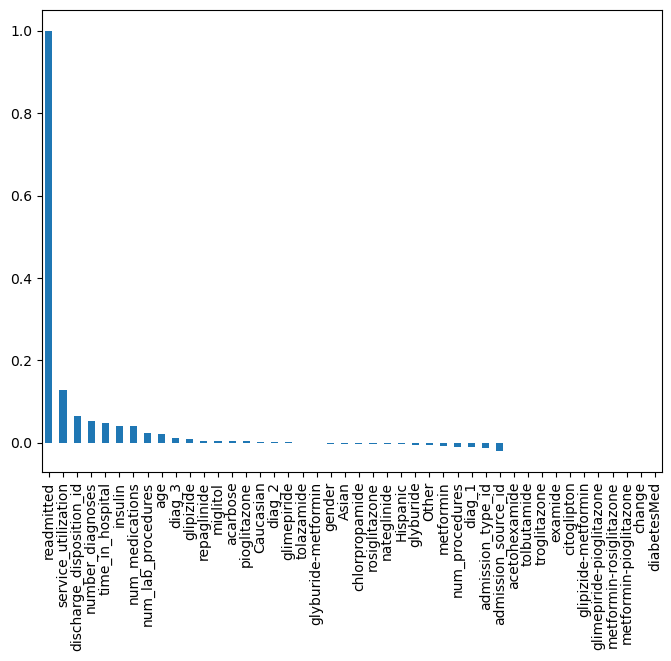

In [55]:
plt.figure(figsize=(8,6))
cor_target.plot(kind='bar')
plt.show()

In [56]:
# List of columns with NaN correlations
columns_to_drop = [
    'acetohexamide', 'tolbutamide', 'troglitazone', 'examide', 'citoglipton',
    'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone',
    'metformin-pioglitazone', 'change', 'diabetesMed'
]

# Drop these columns from the DataFrame
df_cleaned = df.drop(columns=columns_to_drop)

In [57]:
# Display the first few rows of the updated DataFrame
df.head()
     

,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,diag_1,...,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,service_utilization,Asian,Caucasian,Hispanic,Other
0,0,5,2,2,1,1,41,0,1,124,...,0,0,1,1,0,0,False,True,False,False
1,0,15,0,0,0,3,59,0,18,143,...,0,0,1,1,0,0,False,True,False,False
2,0,25,0,0,0,2,11,5,13,454,...,0,0,1,1,0,3,False,False,False,False
3,1,35,0,0,0,2,44,1,16,554,...,0,0,1,1,0,0,False,True,False,False
4,1,45,0,0,0,1,51,0,8,54,...,0,0,1,1,0,0,False,True,False,False


In [58]:
from sklearn.model_selection import train_test_split

# Separate the features (X) and the target variable (y) from the dataset
X = df.drop('readmitted', axis=1)
y = df.readmitted

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

print('X_train', X_train.shape)
print('y_train', y_train.shape)
print('X_test', X_test.shape)
print('y_test', y_test.shape)
     

X_train (69526, 43)
y_train (69526,)
X_test (29797, 43)
y_test (29797,)


In [59]:

scores = pd.DataFrame(columns=['Model_Name', 'Test_Accuracy', 'Test_f1', 'Test_precision', 'Test_recall', 'Test_auc_roc'])

In [60]:
from sklearn.impute import SimpleImputer

# Replace 'mean' with 'median' or 'most_frequent' as needed
imputer = SimpleImputer(strategy='mean')

# Replace missing values in the training-testing data with the computed mean
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [66]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split, cross_val_score
scores = pd.DataFrame(columns=[
    "Model_Name",
    "Test_Accuracy",
    "Test_f1",
    "Test_precision",
    "Test_recall",
    "Test_auc_roc"
])

def evaluate_model(pipe, X_train, y_train, X_test, y_test, model_name="Model"):
    # Train the model
    pipe.fit(X_train, y_train)
    print(model_name+":")

    # Training Accuracy
    tr_acc = pipe.score(X_train, y_train)
    print(f"Training Accuracy: {tr_acc}")

    # Testing Accuracy
    te_acc = pipe.score(X_test, y_test)
    print(f"Testing Accuracy: {te_acc}")

    # Cross-validation score
    score = cross_val_score(estimator=pipe, X=X_train, y=y_train, scoring='accuracy', cv=5)
    print('Cross validation score', np.mean(score))

    # Predictions
    pred = pipe.predict(X_test)

    # Metrics for Test Data
    test_conf_matrix = confusion_matrix(y_test, pred)
    print(f"Confusion Matrix (Test):\n{test_conf_matrix}")
    test_class_report = classification_report(y_test, pred)
    print(f"Classification Report (Test):\n{test_class_report}")
    test_precision = precision_score(y_test, pred)
    test_recall = recall_score(y_test, pred)
    test_f1 = f1_score(y_test, pred)
    test_roc_auc = roc_auc_score(y_test, pred)

    # Collect results in a pandas Series
    add = pd.Series({
        'Model_Name': model_name,
        'Test_Accuracy': te_acc,
        'Test_f1': test_f1,
        'Test_recall': test_recall,
        'Test_precision': test_precision,
        'Test_auc_roc': test_roc_auc
    })

    # Append results to global scores DataFrame
    global scores
    scores = pd.concat([scores, pd.DataFrame([add])], ignore_index=True)

    return scores

from sklearn.metrics import roc_curve, auc

def plot_roc_curve(model, X_test, y_test):
    # Predicting probabilities for the positive class (1)
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    # Plot the ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters found: {'C': 1, 'max_iter': 100, 'penalty': 'l2', 'solver': 'saga'}
Logistic Regression:
Training Accuracy: 0.6432413773264678
Testing Accuracy: 0.643890324529315
Cross validation score 0.6431551083757368
Confusion Matrix (Test):
[[17405  8988]
 [ 1623  1781]]
Classification Report (Test):
              precision    recall  f1-score   support

           0       0.91      0.66      0.77     26393
           1       0.17      0.52      0.25      3404

    accuracy                           0.64     29797
   macro avg       0.54      0.59      0.51     29797
weighted avg       0.83      0.64      0.71     29797



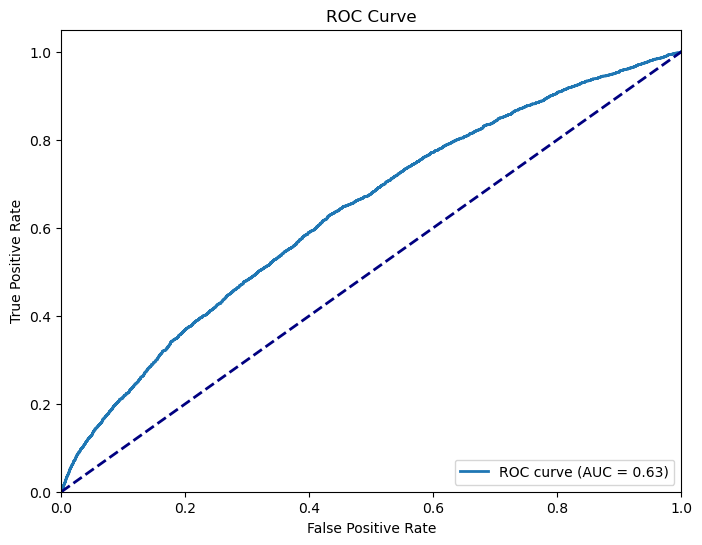

In [67]:
#logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Define the Logistic Regression model
lr_model = LogisticRegression(class_weight="balanced", random_state=42)

# Define hyperparameters for GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10],          # Regularization strength
    'penalty': ['l2'],                # Using L2 regularization (default)
    'solver': ['liblinear', 'saga'],  # Suitable solvers for small datasets
    'max_iter': [100, 200, 300]       # Maximum iterations for convergence
}

# Perform GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(lr_model, param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Best parameters found by GridSearchCV
print(f"Best parameters found: {grid_search.best_params_}")

# Use the best model from GridSearchCV
best_model = grid_search.best_estimator_

# Evaluate the model using the existing evaluate_model function
evaluate_model(best_model, X_train, y_train, X_test, y_test, model_name="Logistic Regression")


# Plot the ROC curve for the best model
plot_roc_curve(best_model, X_test, y_test)
     

Decision Tree Classifier:
Training Accuracy: 0.8958485482902446
Testing Accuracy: 0.8519649629157298
Cross validation score 0.8926923557861709
Confusion Matrix (Test):
[[24909  1484]
 [ 2927   477]]
Classification Report (Test):
              precision    recall  f1-score   support

           0       0.89      0.94      0.92     26393
           1       0.24      0.14      0.18      3404

    accuracy                           0.85     29797
   macro avg       0.57      0.54      0.55     29797
weighted avg       0.82      0.85      0.83     29797



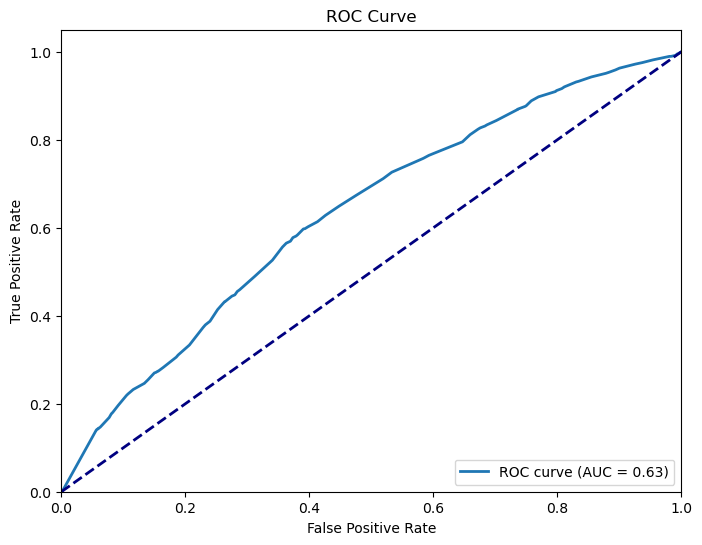

In [68]:
#model2:decision tree classifier
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE

# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Initialize the Decision Tree Classifier
dt_model = DecisionTreeClassifier(
    max_depth=10,                # Restrict tree depth to prevent overfitting
    min_samples_split=5,         # Minimum samples to split a node
    min_samples_leaf=5,          # Minimum samples required in a leaf node
    criterion='gini',            # Use Gini impurity as the splitting criterion
    class_weight='balanced',     # Handle class imbalance by assigning weights to classes
    random_state=42              # Ensure reproducibility
)

# Use the evaluate_model function directly
evaluate_model(dt_model, X_train_smote, y_train_smote, X_test, y_test, model_name="Decision Tree Classifier")

# Plot the ROC curve using your existing function
plot_roc_curve(dt_model, X_test, y_test)

Random Forest Classifier:
Training Accuracy: 0.9289076066669912
Testing Accuracy: 0.8854582676108333
Cross validation score 0.9261004523694414
Confusion Matrix (Test):
[[26368    25]
 [ 3388    16]]
Classification Report (Test):
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     26393
           1       0.39      0.00      0.01      3404

    accuracy                           0.89     29797
   macro avg       0.64      0.50      0.47     29797
weighted avg       0.83      0.89      0.83     29797



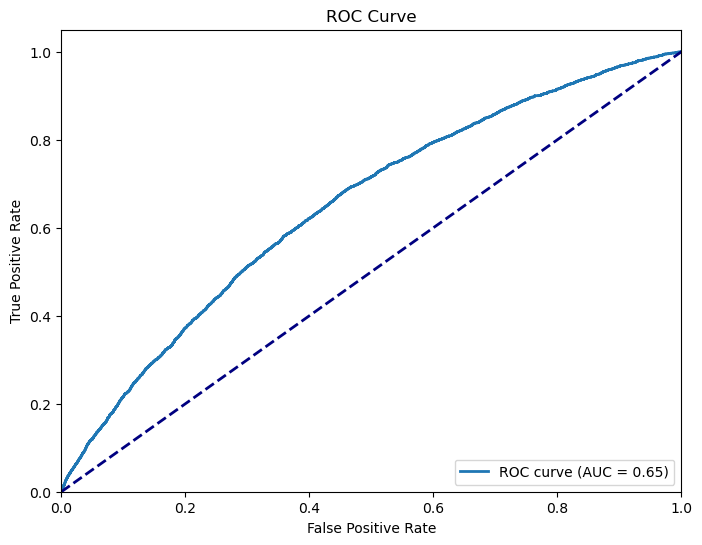

In [69]:
#model3 Random forest classifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=300,           # Number of trees in the forest
    max_depth=15,               # Maximum depth of the trees
    min_samples_split=10,       # Minimum number of samples to split a node
    min_samples_leaf=5,         # Minimum samples required to be at a leaf node
    max_features='sqrt',        # Use square root of the total features for better splits
    class_weight='balanced',    # Adjust class weights to handle imbalance
    random_state=42,            # Ensure reproducibility
    n_jobs=-1                   # Use all available CPU cores for faster training
)

# Evaluate the model using the evaluate_model function
evaluate_model(rf_model, X_train_smote, y_train_smote, X_test, y_test, model_name="Random Forest Classifier")

# Plot the ROC curve for the model using the existing function
plot_roc_curve(rf_model, X_test, y_test)

XGB Classifier:
Training Accuracy: 0.8852264797052761
Testing Accuracy: 0.7719569084135987
Cross validation score 0.8260872812434219
Confusion Matrix (Test):
[[21754  4639]
 [ 2156  1248]]
Classification Report (Test):
              precision    recall  f1-score   support

           0       0.91      0.82      0.86     26393
           1       0.21      0.37      0.27      3404

    accuracy                           0.77     29797
   macro avg       0.56      0.60      0.57     29797
weighted avg       0.83      0.77      0.80     29797



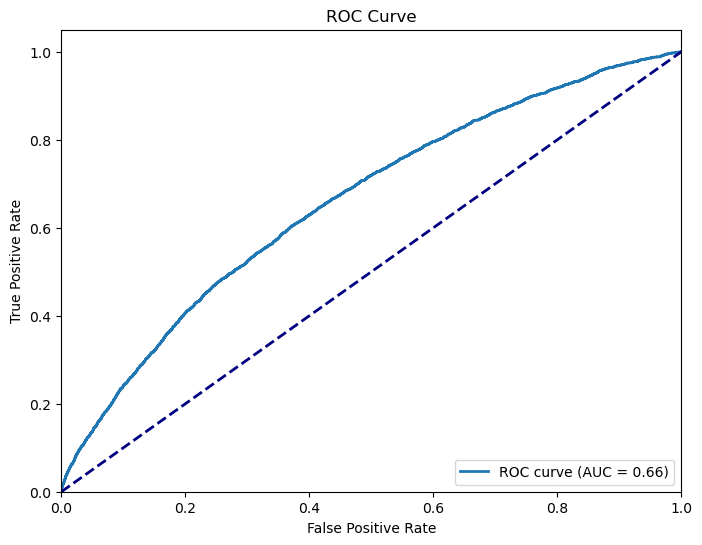

In [70]:
#model4 xgboost classifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Initialize the XGBoost Classifier
xgb_model = XGBClassifier(
    max_depth=7,               # Increased tree depth for better learning
    learning_rate=0.05,        # Reduced learning rate for better generalization
    n_estimators=150,          # Increased boosting rounds for more robust learning
    subsample=0.9,             # Increased subsample to use more data for each tree
    colsample_bytree=0.9,      # Increased feature subsampling for more diversity
    scale_pos_weight=5,        # Adjusted scale_pos_weight to handle class imbalance better
    random_state=42,           # Ensure reproducibility
    n_jobs=-1,                 # Use all available CPU cores for faster training
    eval_metric='logloss'      # Set eval_metric to logloss for better monitoring during training
)

# Use the evaluate_model function directly
evaluate_model(xgb_model, X_train_smote, y_train_smote, X_test, y_test, model_name="XGB Classifier")

# Plot the ROC curve using your existing function
plot_roc_curve(xgb_model, X_test, y_test)

In [71]:
scores

,Model_Name,Test_Accuracy,Test_f1,Test_precision,Test_recall,Test_auc_roc
0,Logistic Regression,0.643890,0.251323,0.165382,0.523208,0.591332
1,Decision Tree Classifier,0.851965,0.177819,0.243243,0.140129,0.541951
2,Random Forest Classifier,0.885458,0.009289,0.390244,0.004700,0.501877
3,XGB Classifier,0.771957,0.268647,0.211993,0.366627,0.595431
